<a href="https://colab.research.google.com/github/dhruvidarji1/Phishing-Email-Prediction-Models/blob/main/MultinomialNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install and import the libraries

In [ ]:
!pip install -q datasets

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Load the dataset

In [ ]:
dataset = load_dataset(
    "simlab-vs/meajor_cleaned_preprocessed"
)

print(dataset)

README.md:   0%|          | 0.00/2.63k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 82.7MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/108685 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sender', 'sender_domain', 'receiver', 'receiver_domain', 'date', 'subject', 'content_types', 'body', 'urls', 'url_count', 'url_length_max', 'url_length_avg', 'url_subdom_max', 'url_subdom_avg', 'attachment_count', 'has_attachments', 'attachment_types', 'language', 'source', 'label'],
        num_rows: 108685
    })
})


In [ ]:
df = dataset["train"].to_pandas()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (108685, 20)


,sender,sender_domain,receiver,receiver_domain,date,subject,content_types,body,urls,url_count,url_length_max,url_length_avg,url_subdom_max,url_subdom_avg,attachment_count,has_attachments,attachment_types,language,source,label
0,d66e9e64b006d6bca649f1c945129c42c43836872b2ead...,enron.com,35c5a9fb9fba3b8737ed7cef2a87e427a73db4fca85f6b...,enron.com,2001-06-29 09:37:04-05:00,[ORGANIZATION] failover plan.,text/plain,"Hi [NAME], \n\nTonight we are rolling out a n...",None,0.0,0.0,0.0,0.0,0.0,0.0,False,None,en,trec5,0.0
1,0907d5c64598aa2639154ed4e1556be615669e40052a1f...,enron.com,aa2c35499eae5999bf6080453cc719a891da2bb0c3803d...,enron.com,2001-06-29 08:39:30-05:00,RE: Intranet Site,text/plain,"[NAME] r these new?\tIntranet Site\n\n[NAME],\...",http://eastpower.dev.corp.enron.com/summary/pj...,3.0,60.0,58.0,3.0,3.0,0.0,False,None,en,trec5,0.0
2,7c3201a5ff8c5985218f1e3f11e330dc0242bbd28c6c20...,enron.com,a736837579feb601fbf6c0657d3d93689774afa6491bb9...,enron.com;enron.com,2001-06-29 10:35:17-05:00,FW: [ORGANIZATION] Company information,text/plain,"[NAME]/[NAME],\n\nWe are currently trading und...",None,0.0,0.0,0.0,0.0,0.0,0.0,False,None,en,trec5,0.0
3,8531d54a169c4af106b9ea2165d4986b8cc10fc0a6bb9b...,enron.com,765a3ec4a67e40118d22de5729b05d090a1b59cb443bf6...,enron.com;enron.com,2001-06-29 10:40:02-05:00,New Master Physical,text/plain,[NAME] and [NAME] -\n\nAttached is a worksheet...,None,0.0,0.0,0.0,0.0,0.0,0.0,False,None,en,trec5,0.0
4,7c3201a5ff8c5985218f1e3f11e330dc0242bbd28c6c20...,enron.com,ce418c97ac415706338972e1dbbd99ebb8c617b5c937a3...,enron.com;enron.com;enron.com,2001-06-29 10:48:00-05:00,FW: [ORGANIZATION]/Mirant GISB,text/plain,FYI. Below is a copy of my communication with ...,None,0.0,0.0,0.0,0.0,0.0,0.0,False,None,en,trec5,0.0


Inspect the dataset

In [ ]:
print(df.columns.tolist())
print()
print(df["label"].value_counts())
print()
print(df[["subject", "body", "label"]].head())

['sender', 'sender_domain', 'receiver', 'receiver_domain', 'date', 'subject', 'content_types', 'body', 'urls', 'url_count', 'url_length_max', 'url_length_avg', 'url_subdom_max', 'url_subdom_avg', 'attachment_count', 'has_attachments', 'attachment_types', 'language', 'source', 'label']

label
0.0    60650
1.0    48034
Name: count, dtype: int64

                                  subject  \
0           [ORGANIZATION] failover plan.   
1                       RE: Intranet Site   
2  FW: [ORGANIZATION] Company information   
3                     New Master Physical   
4          FW: [ORGANIZATION]/Mirant GISB   

                                                body  label  
0  Hi [NAME],  \n\nTonight we are rolling out a n...    0.0  
1  [NAME] r these new?\tIntranet Site\n\n[NAME],\...    0.0  
2  [NAME]/[NAME],\n\nWe are currently trading und...    0.0  
3  [NAME] and [NAME] -\n\nAttached is a worksheet...    0.0  
4  FYI. Below is a copy of my communication with ...    0.0  


In [ ]:
print(df["label"].unique())

[ 0.  1. nan]


Check for missing values

In [ ]:
print(df[["subject", "body", "label"]].isnull().sum())

subject    1455
body          1
label         1
dtype: int64


In [ ]:
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")

In [ ]:
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)

Combine the subject and body

In [ ]:
df["email_text"] = (
    df["subject"].astype(str)
    + " "
    + df["body"].astype(str)
)

In [ ]:
print(df[["subject", "body", "email_text", "label"]].head())

                                  subject  \
0           [ORGANIZATION] failover plan.   
1                       RE: Intranet Site   
2  FW: [ORGANIZATION] Company information   
3                     New Master Physical   
4          FW: [ORGANIZATION]/Mirant GISB   

                                                body  \
0  Hi [NAME],  \n\nTonight we are rolling out a n...   
1  [NAME] r these new?\tIntranet Site\n\n[NAME],\...   
2  [NAME]/[NAME],\n\nWe are currently trading und...   
3  [NAME] and [NAME] -\n\nAttached is a worksheet...   
4  FYI. Below is a copy of my communication with ...   

                                          email_text  label  
0  [ORGANIZATION] failover plan. Hi [NAME],  \n\n...      0  
1  RE: Intranet Site [NAME] r these new?\tIntrane...      0  
2  FW: [ORGANIZATION] Company information [NAME]/...      0  
3  New Master Physical [NAME] and [NAME] -\n\nAtt...      0  
4  FW: [ORGANIZATION]/Mirant GISB FYI. Below is a...      0  


Remove empty emails

In [ ]:
df = df[df["email_text"].str.strip() != ""]

print("Rows remaining:", len(df))

Rows remaining: 108684


In [ ]:
X = df["email_text"]
y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training emails:", len(X_train))
print("Testing emails:", len(X_test))

print("\nTraining label counts:")
print(y_train.value_counts())

print("\nTesting label counts:")
print(y_test.value_counts())

Training emails: 86947
Testing emails: 21737

Training label counts:
label
0    48520
1    38427
Name: count, dtype: int64

Testing label counts:
label
0    12130
1     9607
Name: count, dtype: int64


Convert the email text into TF-IDF numbers

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

Training matrix shape: (86947, 20000)
Testing matrix shape: (21737, 20000)


Train the Multinomial Naive Bayes model

In [ ]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

MultinomialNB()

Make Predictions

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,0,0
4,1,1
5,0,0
6,1,1
7,0,0
8,0,0
9,0,0


Calculate model performance

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Accuracy: 0.9584
Precision: 0.9727
Recall: 0.932
F1 Score: 0.9519


In [ ]:
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1 Score:  {f1 * 100:.2f}%")

Accuracy:  95.84%
Precision: 97.27%
Recall:    93.20%
F1 Score:  95.19%


Print the classification report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Phishing"]
    )
)

              precision    recall  f1-score   support

  Legitimate       0.95      0.98      0.96     12130
    Phishing       0.97      0.93      0.95      9607

    accuracy                           0.96     21737
   macro avg       0.96      0.96      0.96     21737
weighted avg       0.96      0.96      0.96     21737



Create a confusion matrix

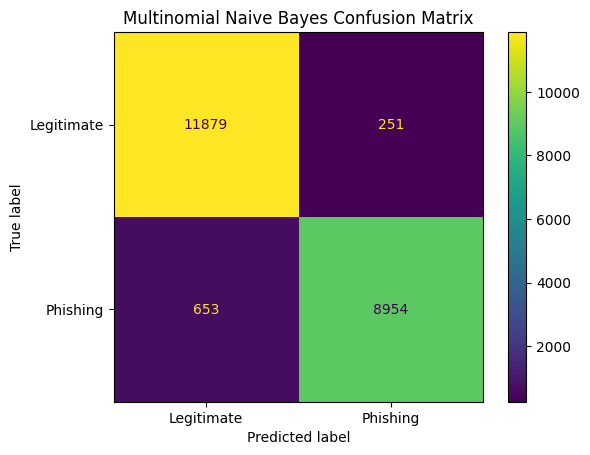

In [ ]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Phishing"]
)

display.plot()
plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.show()